In [1]:
# Multiple Linear Regression
import seaborn as sns
%matplotlib inline
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
# Load your dataset
data = pd.read_csv('/home/atom/PycharmProjects/Tensorflow2/DS/Machine-Learning-Notes/Lec1/Multiple_Linear_Regression/50_Startups.csv')
data

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
print(data.columns)

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')


In [5]:
# Define your features (independent variables) and target (dependent variable)
X = data[['R&D Spend', 'Administration', 'Marketing Spend', 'State']]
y = data['Profit']


In [6]:
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [7]:
data.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [8]:
data.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

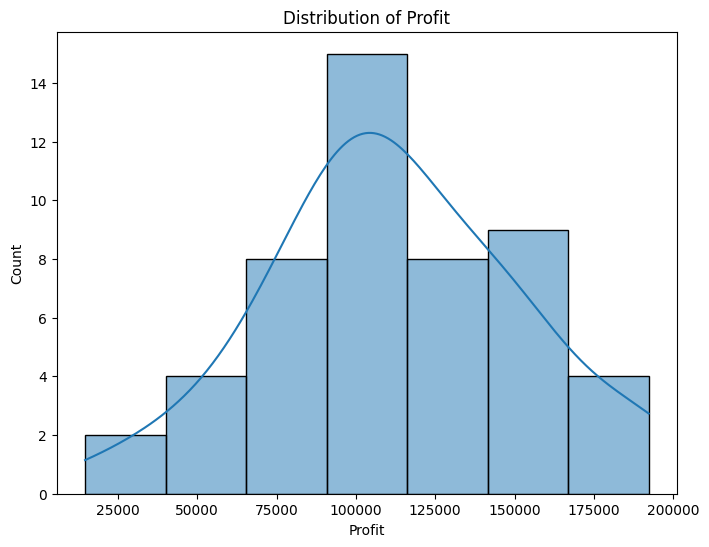

In [9]:
import seaborn as sns

# Histogram of 'Profit'
plt.figure(figsize=(8, 6))
sns.histplot(data['Profit'], kde=True)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.show()


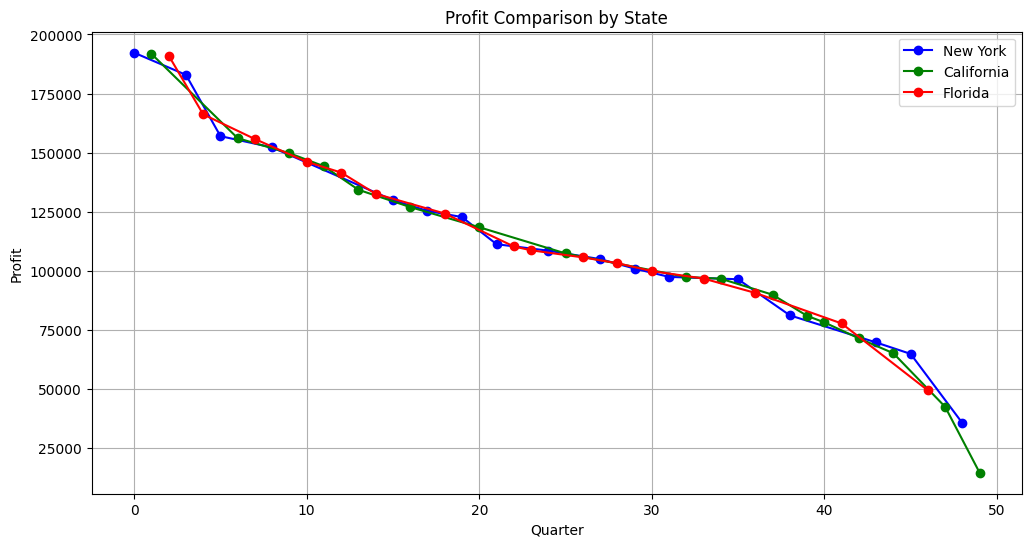

In [10]:
# Filter the data for each state
ny_data = data[data['State'] == 'New York']
ca_data = data[data['State'] == 'California']
fl_data = data[data['State'] == 'Florida']

# Create the line chart
plt.figure(figsize=(12, 6))
plt.plot(ny_data['Profit'], label='New York', color='blue', marker='o')
plt.plot(ca_data['Profit'], label='California', color='green', marker='o')
plt.plot(fl_data['Profit'], label='Florida', color='red', marker='o')

plt.title('Profit Comparison by State')
plt.xlabel('Quarter')
plt.ylabel('Profit')
plt.legend()
plt.grid(True)
plt.show()


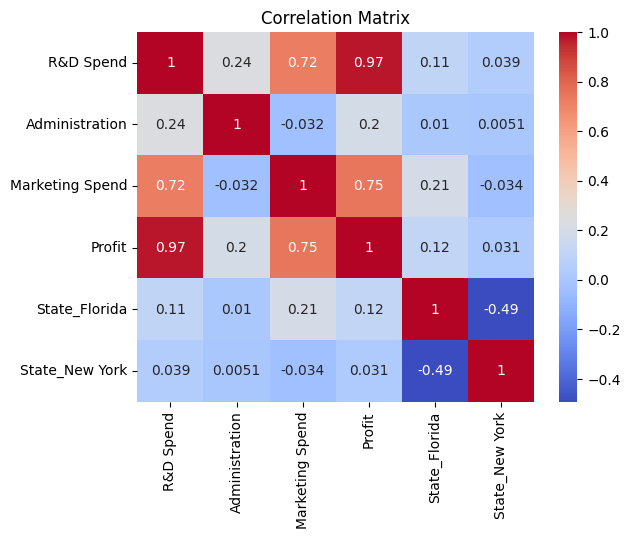

In [11]:
# Perform one-hot encoding on the 'State' column
data = pd.get_dummies(data, columns=['State'], drop_first=True)

correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [12]:
X = pd.get_dummies(X, columns=['State'], drop_first=True)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Create and fit the regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [19]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

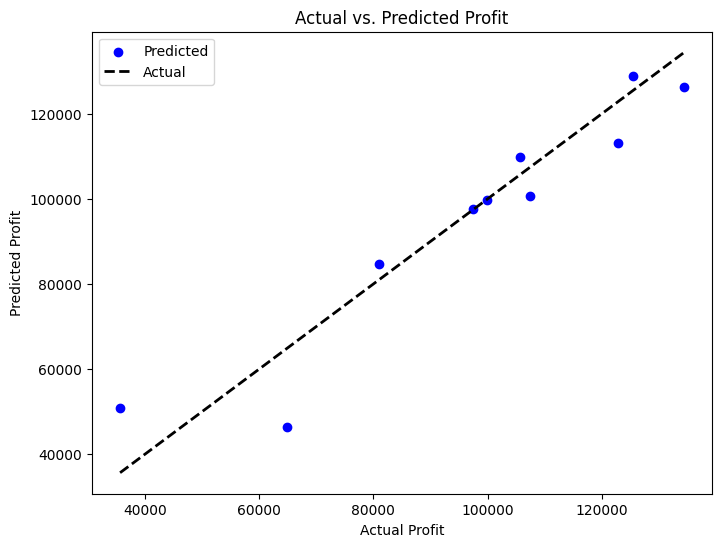

Mean Squared Error: 82010363.04430099
R-squared: 0.8987266414328637


In [22]:
# Create a scatter plot to visualize actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs. Predicted Profit")

# Add a diagonal line for comparison
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.legend(["Predicted", "Actual"])

plt.show()

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

The Mean Squared Error (MSE) and R-squared (R²) are common evaluation metrics used to assess the performance of a regression model. I'll explain the mathematical steps for calculating these metrics based on the values you provided:

1. Mean Squared Error (MSE):
   The Mean Squared Error measures the average of the squared differences between the actual (observed) values and the predicted values. It quantifies the model's prediction error.

   MSE = Σ (actual - predicted)² / n

   Where:
   - Σ represents the summation (sum of all terms).
   - (actual - predicted)² represents the squared difference between each actual and predicted value.
   - n is the number of data points.

   In your case, you've provided MSE as 82010363.04430099, so you can rearrange the equation to solve for the sum of squared differences:

   Sum of squared differences = MSE * n

   If you know the number of data points (n), you can calculate the sum of squared differences using this formula.

2. R-squared (R²):
   R-squared, also known as the coefficient of determination, measures the proportion of the variance in the dependent variable (Y) that is predictable from the independent variables (X) in the regression model. It ranges from 0 to 1, with higher values indicating a better fit.

   R² = 1 - (SSR / SST)

   Where:
   - SSR (Sum of Squares of Residuals) is the sum of the squared differences between the actual values and the predicted values.
   - SST (Total Sum of Squares) is the sum of the squared differences between the actual values and the mean of the actual values.

   R² = 1 - (MSE * n) / (Σ (actual - mean(actual))²)

   In your case, you've provided R-squared as 0.8987266414328637. To calculate R², you can rearrange the equation as follows:

   SSR = (1 - R²) * SST

   Where SST is the sum of the squared differences between the actual values and the mean of the actual values. If you have the mean of the actual values and the number of data points, you can calculate SST, and then use the formula above to calculate SSR.


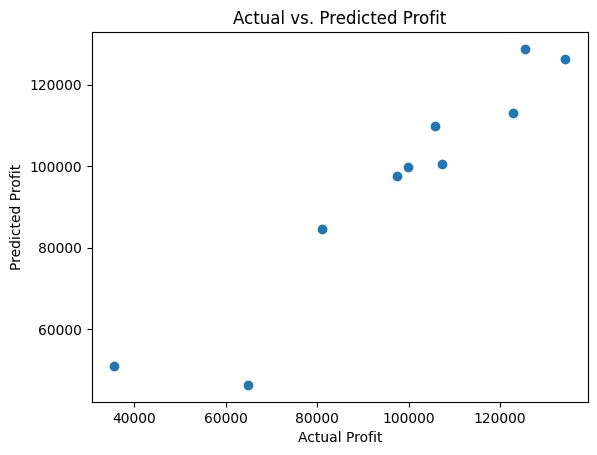

In [23]:
# Visualize the actual vs. predicted values
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs. Predicted Profit")
plt.show()


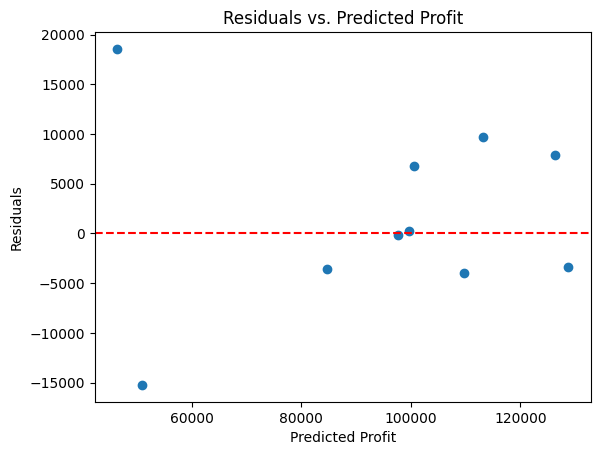

In [24]:
# Visualize the residuals (difference between actual and predicted values)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Profit")
plt.ylabel("Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals vs. Predicted Profit")
plt.show()


Residuals, in the context of linear regression or other statistical modeling, refer to the differences between the observed or actual values of the dependent variable (the target variable) and the predicted values made by the regression model. These differences are often called "residual errors" or simply "residuals."

In the context of linear regression, the residuals represent how much the actual data points deviate from the predicted values based on the regression equation. The residual for each data point is calculated as:

Residual = Observed Value - Predicted Value

Here's what the terms mean:

- Observed Value: The actual value of the dependent variable for a specific data point.
- Predicted Value: The value predicted by the linear regression model for the same data point.

